# COVID-19 Mortality Across Countries: An Exploratory Data Analysis

## Project Overview

The COVID-19 pandemic affected countries very differently, with substantial variation in infection rates, mortality rates, vaccination uptake, government responses, and healthcare resources. Understanding these differences may provide insight into factors associated with better or worse pandemic outcomes.

This project combines data from multiple sources, including:

- Our World in Data (OWID) COVID-19 statistics
- Oxford COVID Government Response Tracker Stringency Index
- World Bank demographic and healthcare indicators

The resulting dataset contains one record per country and includes measures of COVID-19 outcomes, vaccination coverage, government response, demographics, economic conditions, healthcare resources, and population density.

The primary outcome of interest is:

**Total COVID-19 deaths per million population**

The objective of this exploratory analysis is to investigate relationships between COVID-19 mortality and potential explanatory variables, identify patterns in the data, assess data quality, and generate hypotheses for subsequent modeling and prediction.


## Load Libraries and Data

The final analytical dataset created during the data wrangling phase will be used throughout this exploratory analysis.

The dataset contains country-level COVID-19 outcomes, vaccination coverage, government response measures, demographic characteristics, healthcare indicators, and economic variables. The following libraries will be used for data manipulation, visualization, and statistical exploration.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os

pd.set_option("display.max_columns", None)

In [3]:
covid = pd.read_csv(
    "../data/processed/covid_analysis_dataset.csv"
)

covid.shape

(239, 22)

## Initial Data Inspection

Before exploring relationships among variables, it is important to verify that the dataset loaded correctly and to understand its structure, dimensions, and variable types.

In [4]:
covid.head()

,country,code,continent,population,total_cases,total_cases_per_million,total_deaths,total_deaths_per_million,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,stringency_index,median_age,gdp_per_capita,hospital_beds_per_thousand,life_expectancy,diabetes_prevalence,iso_code,country_wb,population_density,health_expenditure_per_capita,health_expenditure_pct_gdp
0,Afghanistan,AFG,Asia,40578847.0,235214.0,5796.4683,7998.0,197.09776,47.195450,45.270844,6.727495,27.394580,16.752001,1983.812622,0.35,65.616997,11.7,AFG,Afghanistan,61.328691,81.521126,21.508444
1,Albania,ALB,Europe,2827614.0,337234.0,119264.5100,3608.0,1275.98740,47.717087,45.244260,14.230054,41.782108,35.943001,21641.074219,2.90,78.768799,10.6,ALB,Albania,90.867226,465.570435,7.357504
2,Algeria,DZA,Africa,45477391.0,272440.0,5990.6690,6881.0,151.30595,17.239624,14.251447,1.265796,48.367728,27.983000,15501.919922,1.61,76.128899,17.5,DZA,Algeria,18.793445,208.939117,5.021889
3,American Samoa,ASM,Oceania,48365.0,8359.0,172831.6000,34.0,702.98770,NaN,NaN,NaN,NaN,27.927000,NaN,NaN,72.752098,NaN,ASM,American Samoa,246.125000,NaN,NaN
4,Andorra,AND,Europe,79722.0,48015.0,602280.4400,159.0,1994.43070,72.643684,67.109460,54.026493,33.486770,42.832001,65928.304688,NaN,84.016403,10.1,AND,Andorra,166.731915,3668.447510,8.646717


In [5]:
covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 22 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              239 non-null    object 
 1   code                                 239 non-null    object 
 2   continent                            239 non-null    object 
 3   population                           237 non-null    float64
 4   total_cases                          233 non-null    float64
 5   total_cases_per_million              233 non-null    float64
 6   total_deaths                         233 non-null    float64
 7   total_deaths_per_million             233 non-null    float64
 8   people_vaccinated_per_hundred        217 non-null    float64
 9   people_fully_vaccinated_per_hundred  215 non-null    float64
 10  total_boosters_per_hundred           208 non-null    float64
 11  stringency_index                

In [6]:
covid.describe().T

,count,mean,std,min,25%,50%,75%,max
population,237.0,3.384130e+07,1.364037e+08,513.000000,397542.000000,5.456796e+06,2.250904e+07,1.425423e+09
total_cases,233.0,3.344073e+06,1.146156e+07,0.000000,25292.000000,1.914960e+05,1.279115e+06,1.034368e+08
total_cases_per_million,233.0,2.083471e+05,2.059958e+05,0.000000,20186.773000,1.355382e+05,3.510781e+05,7.698068e+05
total_deaths,233.0,3.054047e+04,1.096326e+05,0.000000,172.000000,1.937000e+03,1.412200e+04,1.238189e+06
total_deaths_per_million,233.0,1.276360e+03,1.338187e+03,0.000000,141.097660,8.893516e+02,2.023351e+03,6.603977e+03
people_vaccinated_per_hundred,217.0,6.261500e+01,2.414233e+01,0.277072,44.640140,6.808708e+01,8.047407e+01,1.120751e+02
people_fully_vaccinated_per_hundred,215.0,5.710050e+01,2.443564e+01,0.272658,39.363430,6.244032e+01,7.592957e+01,1.101884e+02
total_boosters_per_hundred,208.0,3.445340e+01,3.111692e+01,0.000000,7.718700,2.841672e+01,5.628939e+01,1.405325e+02
stringency_index,185.0,4.267543e+01,9.638693e+00,11.333896,36.689361,4.327304e+01,4.919622e+01,7.331321e+01
median_age,237.0,3.120876e+01,9.735554e+00,14.298000,22.243999,3.169800e+01,3.908000e+01,5.987500e+01


## Distribution of COVID-19 Mortality

The primary outcome of interest in this project is total COVID-19 deaths per million population. Before examining relationships with other variables, it is useful to understand the distribution of mortality across countries.

Summary statistics and visualizations will be used to identify the range, central tendency, variability, and potential outliers in the mortality data.

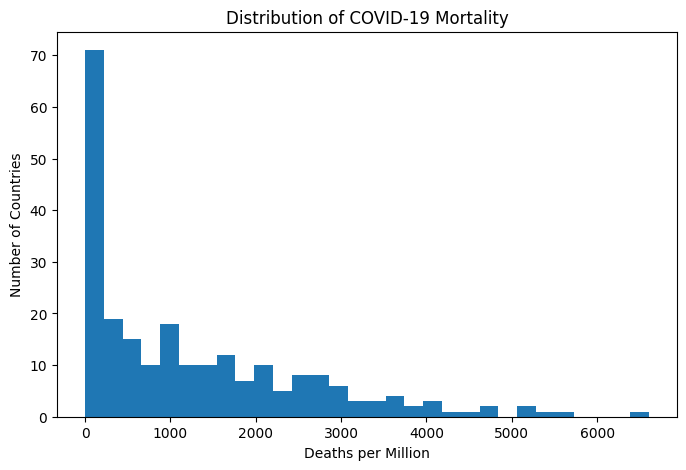

In [7]:
plt.figure(figsize=(8,5))

plt.hist(
    covid["total_deaths_per_million"].dropna(),
    bins=30
)

plt.xlabel("Deaths per Million")
plt.ylabel("Number of Countries")
plt.title("Distribution of COVID-19 Mortality")

plt.show()

In [10]:
covid["total_deaths_per_million"].describe()

count     233.000000
mean     1276.360494
std      1338.187119
min         0.000000
25%       141.097660
50%       889.351600
75%      2023.350700
max      6603.976600
Name: total_deaths_per_million, dtype: float64

### Distribution of COVID-19 Mortality

The distribution of total COVID-19 deaths per million population varies substantially across countries. Mortality rates range from 0 deaths per million to more than 6,600 deaths per million.

The median mortality rate is approximately 889 deaths per million, while the mean is approximately 1,276 deaths per million. Because the mean exceeds the median, the distribution appears to be positively skewed, with a relatively small number of countries experiencing exceptionally high mortality rates.

Because the mean exceeds the median, the distribution appears to be positively skewed, suggesting that a relatively small number of countries experienced exceptionally high mortality rates. The wide range of observed values, from 0 to more than 6,600 deaths per million, indicates substantial heterogeneity in pandemic outcomes across countries.

The large standard deviation relative to the mean further indicates substantial variability in mortality outcomes across countries. This suggests that country-level characteristics such as demographics, healthcare resources, vaccination coverage, and government responses may be important factors to investigate in subsequent analyses.

### Countries with the Highest COVID-19 Mortality

Examining the countries with the highest COVID-19 mortality rates provides an initial understanding of the outcome variable and helps identify potential outliers. Mortality is measured as total COVID-19 deaths per million population, allowing comparisons across countries of different sizes.

In [11]:
covid[
    ["country", "total_deaths_per_million"]
].sort_values(
    "total_deaths_per_million",
    ascending=False
).head(15)

,country,total_deaths_per_million
166,Peru,6603.9766
31,Bulgaria,5681.0405
156,North Macedonia,5429.1950
26,Bosnia and Herzegovina,5123.2495
94,Hungary,5072.5360
49,Croatia,4813.1177
195,Slovenia,4686.9585
77,Georgia,4519.6274
140,Montenegro,4317.9116
53,Czechia,4116.0040


### Countries with the Highest Mortality Rates

Several Eastern and Southeastern European countries appear among the highest mortality rates observed in the dataset. Peru experienced the highest mortality rate, exceeding 6,600 deaths per million population. These countries represent potential outliers and may warrant additional investigation during subsequent analyses.

## Missing Data Assessment

Before exploring relationships among variables, it is important to assess the extent of missing data in the final analytical dataset. Missing values can affect summary statistics, visualizations, and predictive models, and may require special handling in later stages of the analysis.

This section examines the completeness of each variable and identifies any potential data quality concerns.

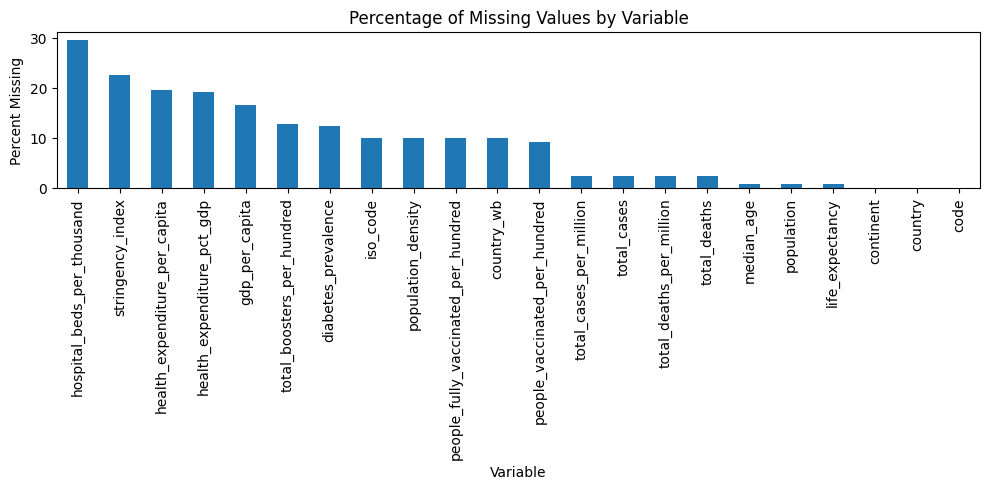

In [15]:
missing_pct = (
    covid.isna()
         .mean()
         .sort_values(ascending=False)
         * 100
)

#missing_pct

plt.figure(figsize=(10,5))

missing_pct.plot(kind="bar")

plt.ylabel("Percent Missing")
plt.xlabel("Variable")
plt.title("Percentage of Missing Values by Variable")

plt.tight_layout()
plt.show()

In [14]:
missing_summary = pd.DataFrame({
    "missing_count": covid.isna().sum(),
    "missing_pct": covid.isna().mean() * 100
})

missing_summary.sort_values(
    "missing_pct",
    ascending=False
)

,missing_count,missing_pct
hospital_beds_per_thousand,71,29.707113
stringency_index,54,22.594142
health_expenditure_per_capita,47,19.665272
health_expenditure_pct_gdp,46,19.246862
gdp_per_capita,40,16.736402
total_boosters_per_hundred,31,12.970711
diabetes_prevalence,30,12.552301
iso_code,24,10.041841
population_density,24,10.041841
people_fully_vaccinated_per_hundred,24,10.041841


In [16]:
covid[covid["iso_code"].isna()][
    ["country", "continent"]
]

,country,continent
6,Anguilla,North America
25,Bonaire Sint Eustatius and Saba,North America
46,Cook Islands,Oceania
68,Falkland Islands,South America
73,French Guiana,South America
84,Guadeloupe,North America
87,Guernsey,Europe
106,Jersey,Europe
111,Kosovo,Europe
131,Martinique,North America


### Missing Data Summary

Several healthcare and economic indicators contain moderate levels of missing data. Hospital beds per thousand has the highest missingness (29.7%), followed by the Stringency Index (22.6%) and the healthcare expenditure variables (approximately 19%).

Inspection of unmatched records indicates that many missing values occur in overseas territories, small island nations, disputed territories, or countries with special political status. This suggests that much of the missingness results from differences in country coverage between data sources rather than data quality issues.

The primary outcome variable, total deaths per million population, is available for more than 97% of countries in the dataset. Therefore, the dataset remains suitable for exploratory analysis and subsequent modeling.

## Correlations with COVID-19 Mortality

In [18]:
numeric_cols = covid.select_dtypes(
    include=np.number
).columns

corr = covid[numeric_cols].corr()

corr["total_deaths_per_million"]\
    .sort_values(ascending=False)

total_deaths_per_million               1.000000
median_age                             0.594032
life_expectancy                        0.448050
total_cases_per_million                0.432106
health_expenditure_pct_gdp             0.354131
gdp_per_capita                         0.345644
hospital_beds_per_thousand             0.312788
health_expenditure_per_capita          0.302545
total_deaths                           0.274135
total_boosters_per_hundred             0.248548
people_fully_vaccinated_per_hundred    0.165786
total_cases                            0.152089
people_vaccinated_per_hundred          0.132816
stringency_index                       0.056677
population_density                     0.014119
population                            -0.072259
diabetes_prevalence                   -0.087495
Name: total_deaths_per_million, dtype: float64

### Correlations with COVID-19 Mortality

Median age exhibited the strongest positive correlation with COVID-19 mortality (r = 0.59), suggesting that countries with older populations generally experienced higher mortality rates. Life expectancy and total reported cases per million also demonstrated moderate positive relationships with mortality.

Several healthcare and economic indicators, including healthcare expenditure, hospital bed availability, and GDP per capita, were positively correlated with mortality. These findings may reflect differences in population age structure and reporting practices rather than direct causal effects.

Vaccination variables displayed relatively weak positive correlations with mortality, while the Stringency Index exhibited almost no linear relationship with mortality. These results highlight the limitations of simple pairwise correlations and suggest that multiple factors may interact to influence pandemic outcomes.

<Axes: xlabel='median_age', ylabel='total_deaths_per_million'>

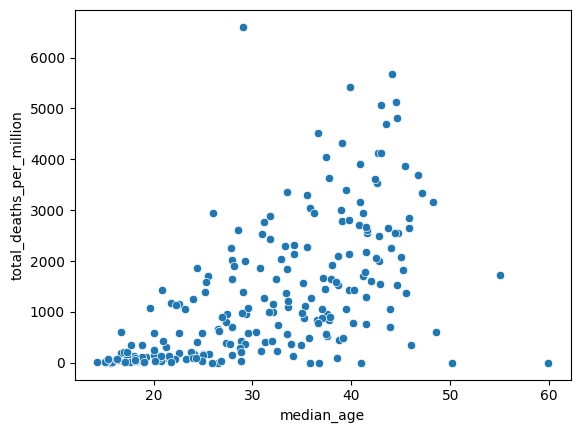

In [20]:
sns.scatterplot(
    data=covid,
    x="median_age",
    y="total_deaths_per_million"
)

### Mortality and Population Age

Median age exhibited the strongest correlation with COVID-19 mortality among the variables examined (r = 0.59). The scatterplot shows a clear positive relationship, with countries having older populations generally experiencing higher mortality rates.

However, the relationship is not deterministic. Countries with similar median ages often experienced substantially different mortality outcomes, suggesting that age alone cannot explain the observed variation. Additional factors such as healthcare resources, vaccination coverage, reporting practices, and government responses may also contribute to differences in mortality.

Several potential outliers are visible, including countries that experienced exceptionally high mortality relative to their median age. These observations may warrant further investigation in subsequent analyses.

### Mortality and COVID-19 Case Rates

A country's mortality rate is expected to be related to the number of COVID-19 infections it experienced. Examining the relationship between total cases per million and total deaths per million may provide insight into whether countries with higher infection rates also tended to experience higher mortality rates.

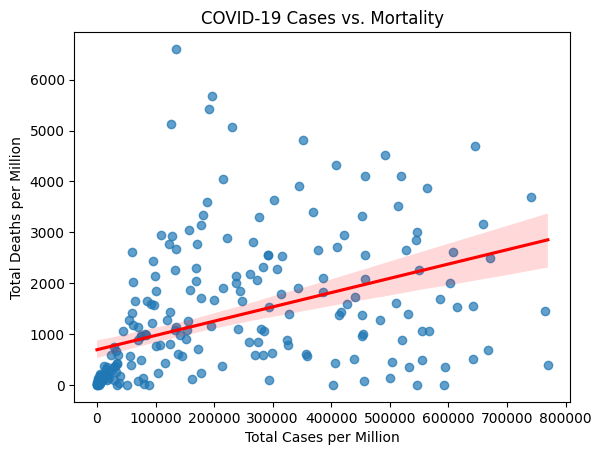

In [21]:
sns.regplot(
    data=covid,
    x="total_cases_per_million",
    y="total_deaths_per_million",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"}
)

plt.xlabel("Total Cases per Million")
plt.ylabel("Total Deaths per Million")
plt.title("COVID-19 Cases vs. Mortality")

plt.show()

### Mortality and COVID-19 Case Rates

The scatterplot reveals a moderate positive relationship between COVID-19 case rates and mortality rates, consistent with the observed correlation coefficient (r = 0.43). Countries with higher numbers of reported infections generally tended to experience higher mortality.

However, considerable variation exists among countries with similar case rates. Some countries experienced substantially higher mortality than others despite reporting comparable numbers of cases. This suggests that infection burden alone cannot fully explain differences in mortality outcomes.

The observed variation may reflect differences in population age structure, healthcare resources, vaccination coverage, reporting practices, and other country-level factors. These results support the continued investigation of additional predictors of COVID-19 mortality.

### Mortality and Life Expectancy

Life expectancy exhibited the second strongest demographic correlation with COVID-19 mortality (r = 0.45). Examining this relationship may provide additional insight into how population health and age structure are associated with pandemic outcomes across countries.

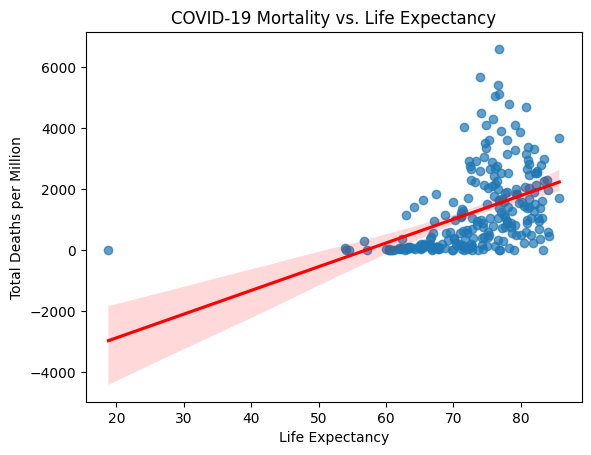

In [22]:
sns.regplot(
    data=covid,
    x="life_expectancy",
    y="total_deaths_per_million",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"}
)

plt.xlabel("Life Expectancy")
plt.ylabel("Total Deaths per Million")
plt.title("COVID-19 Mortality vs. Life Expectancy")

plt.show()

In [23]:
covid.loc[covid["life_expectancy"].idxmin(),
          ["country", "life_expectancy", "total_deaths_per_million"]]

country                     Central African Republic
life_expectancy                            18.817699
total_deaths_per_million                    22.16539
Name: 39, dtype: object

The scatterplot includes a small number of countries with unusually low life expectancy values relative to the rest of the dataset. These observations appear to represent genuine country characteristics rather than data errors and were retained in the analysis.

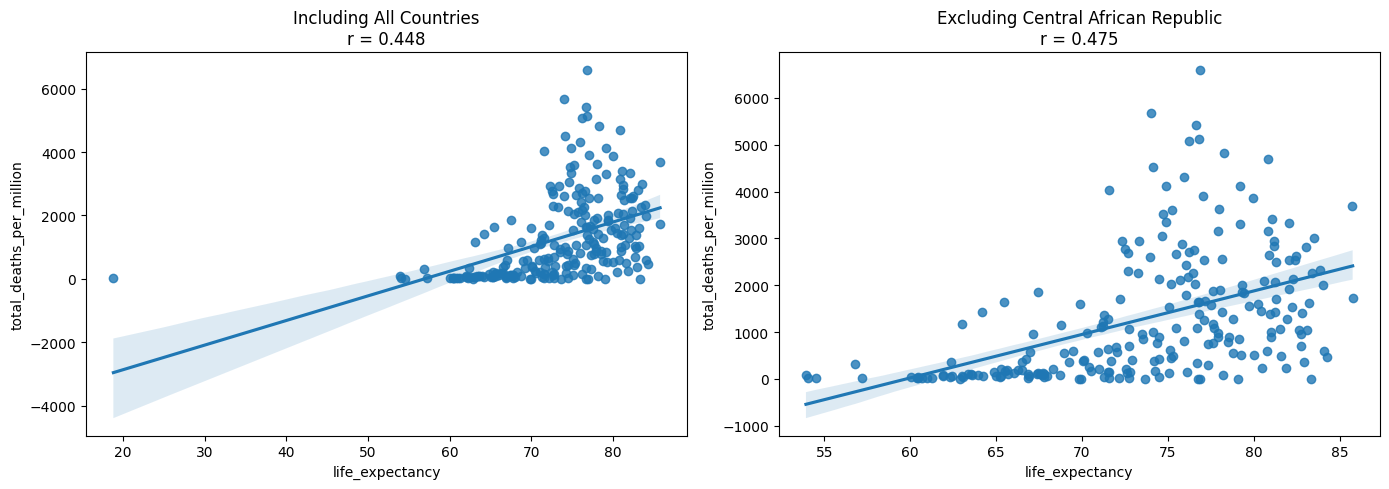

In [25]:
covid_no_car = covid[
    covid["country"] != "Central African Republic"
]

corr_all = covid["life_expectancy"].corr(
    covid["total_deaths_per_million"]
)

corr_no_car = covid_no_car["life_expectancy"].corr(
    covid_no_car["total_deaths_per_million"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    data=covid,
    x="life_expectancy",
    y="total_deaths_per_million",
    ax=axes[0]
)

axes[0].set_title(
    f"Including All Countries\nr = {corr_all:.3f}"
)

sns.regplot(
    data=covid_no_car,
    x="life_expectancy",
    y="total_deaths_per_million",
    ax=axes[1]
)

axes[1].set_title(
    f"Excluding Central African Republic\nr = {corr_no_car:.3f}"
)

plt.tight_layout()
plt.show()

### Sensitivity Analysis

Because the Central African Republic exhibited an unusually low life expectancy relative to the remainder of the dataset, a sensitivity analysis was performed to assess its influence on the observed relationship between life expectancy and COVID-19 mortality.

The correlation between life expectancy and mortality increased only slightly from 0.448 to 0.475 after excluding the Central African Republic. This suggests that the positive association is not driven by a single outlier and remains broadly consistent across the dataset.

## Comparison of Key Predictors

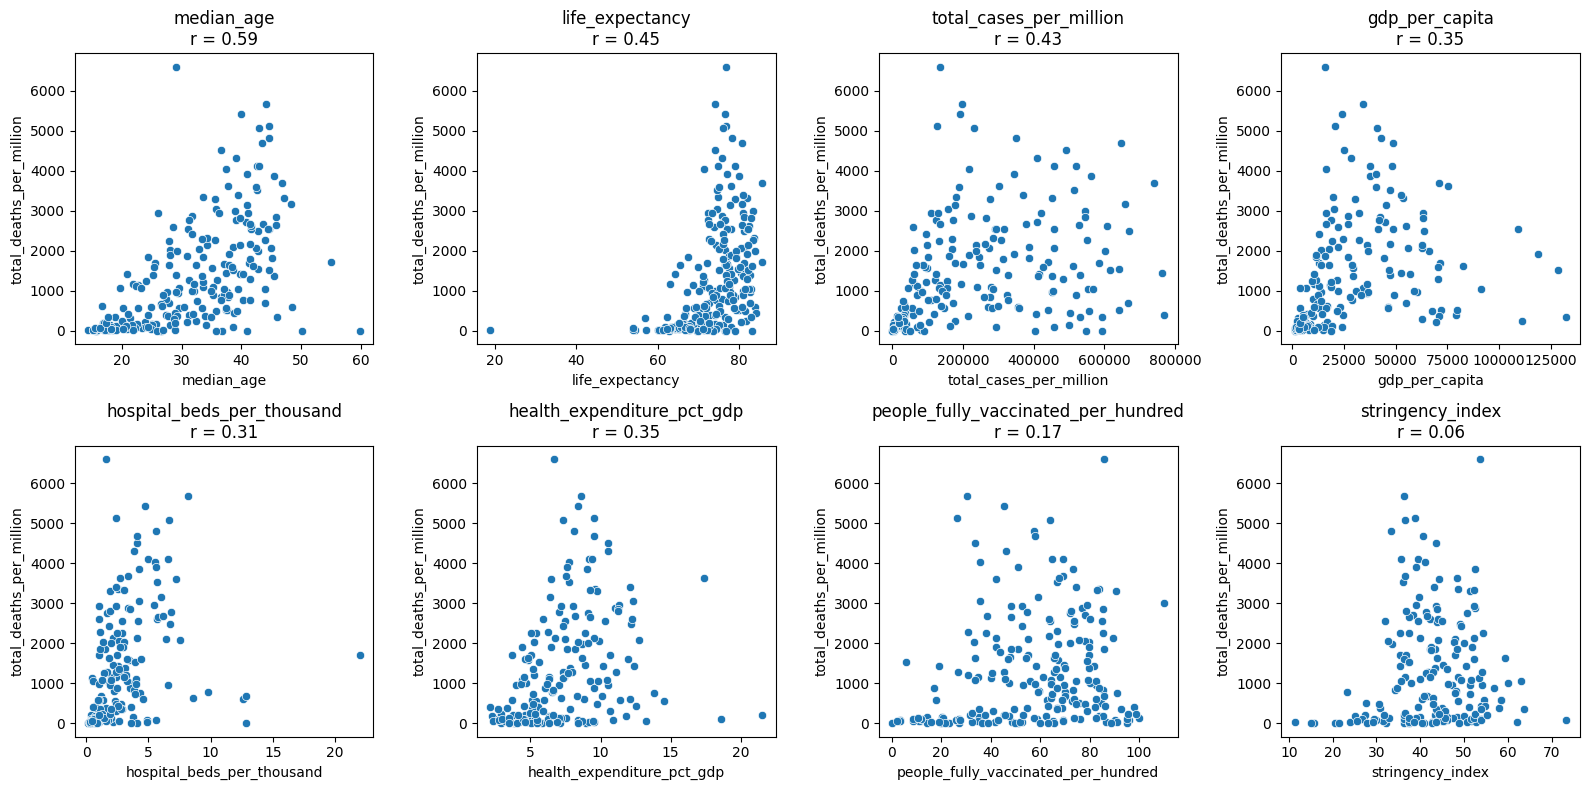

In [26]:
predictors = [
    "median_age",
    "life_expectancy",
    "total_cases_per_million",
    "gdp_per_capita",
    "hospital_beds_per_thousand",
    "health_expenditure_pct_gdp",
    "people_fully_vaccinated_per_hundred",
    "stringency_index"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, var in zip(axes.flatten(), predictors):

    sns.scatterplot(
        data=covid,
        x=var,
        y="total_deaths_per_million",
        ax=ax
    )

    corr = covid[var].corr(
        covid["total_deaths_per_million"]
    )

    ax.set_title(f"{var}\nr = {corr:.2f}")

plt.tight_layout()
plt.show()

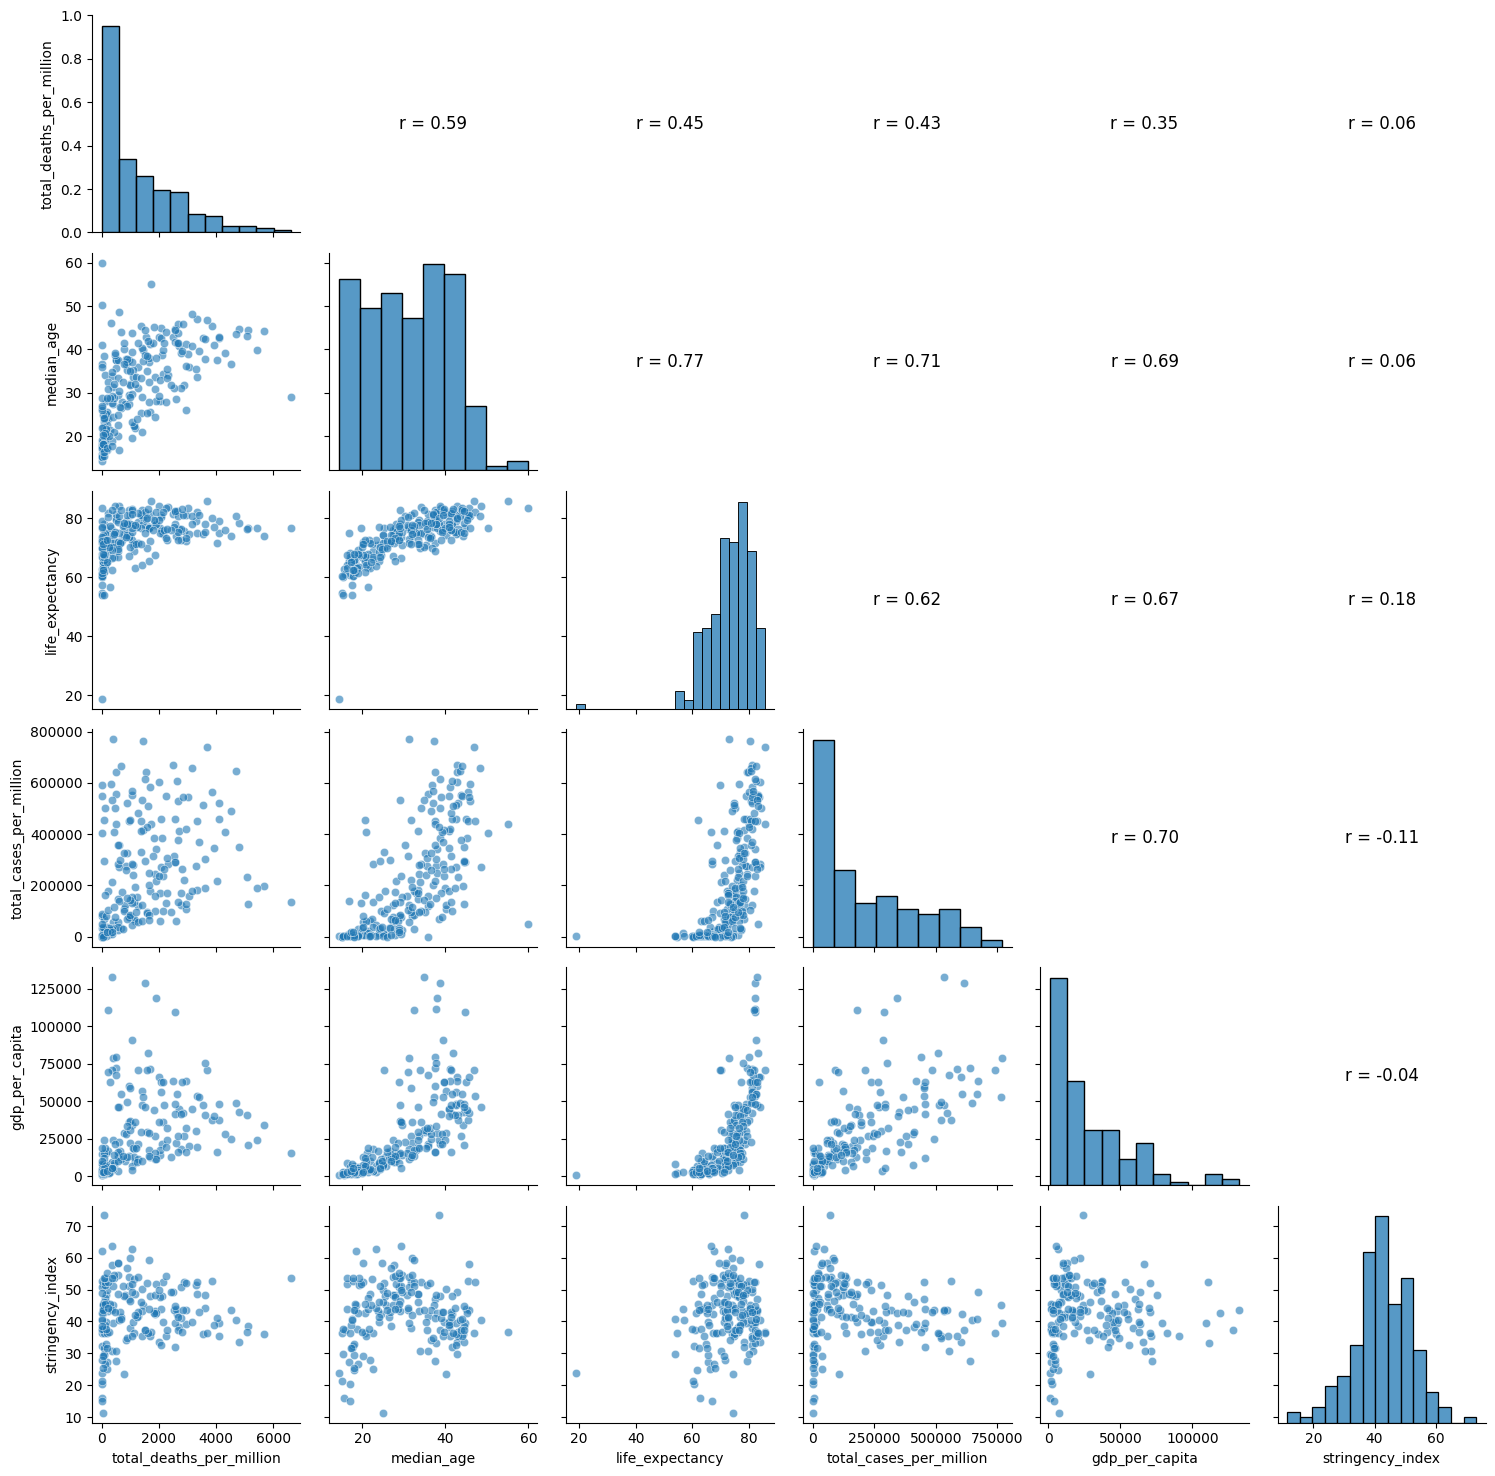

In [27]:
pair_vars = [
    "total_deaths_per_million",
    "median_age",
    "life_expectancy",
    "total_cases_per_million",
    "gdp_per_capita",
    "stringency_index"
]

def corrfunc(x, y, **kws):
    r = x.corr(y)
    ax = plt.gca()
    ax.annotate(
        f"r = {r:.2f}",
        xy=(0.5, 0.5),
        xycoords=ax.transAxes,
        ha="center",
        va="center",
        fontsize=12
    )
    ax.set_axis_off()

g = sns.PairGrid(
    covid[pair_vars],
    corner=False,
    diag_sharey=False
)

g.map_lower(sns.scatterplot, alpha=0.6)
g.map_diag(sns.histplot)
g.map_upper(corrfunc)

plt.show()

## Relationships Among Key Variables

A pairwise analysis was conducted to examine relationships among the primary outcome variable and several demographic, economic, epidemiological, and policy-related indicators.

Several strong positive relationships were observed among predictor variables. Median age and life expectancy were highly correlated (r = 0.77), suggesting that both variables capture similar aspects of population age structure. GDP per capita was also positively associated with life expectancy (r = 0.67) and reported cases per million (r = 0.70).

In contrast, the Stringency Index exhibited weak correlations with all examined variables, indicating that average government response levels were not strongly associated with the country-level measures included in this analysis.

These findings suggest that some predictors may contain overlapping information and should be evaluated carefully during subsequent modeling efforts.

## Vaccination and Government Response

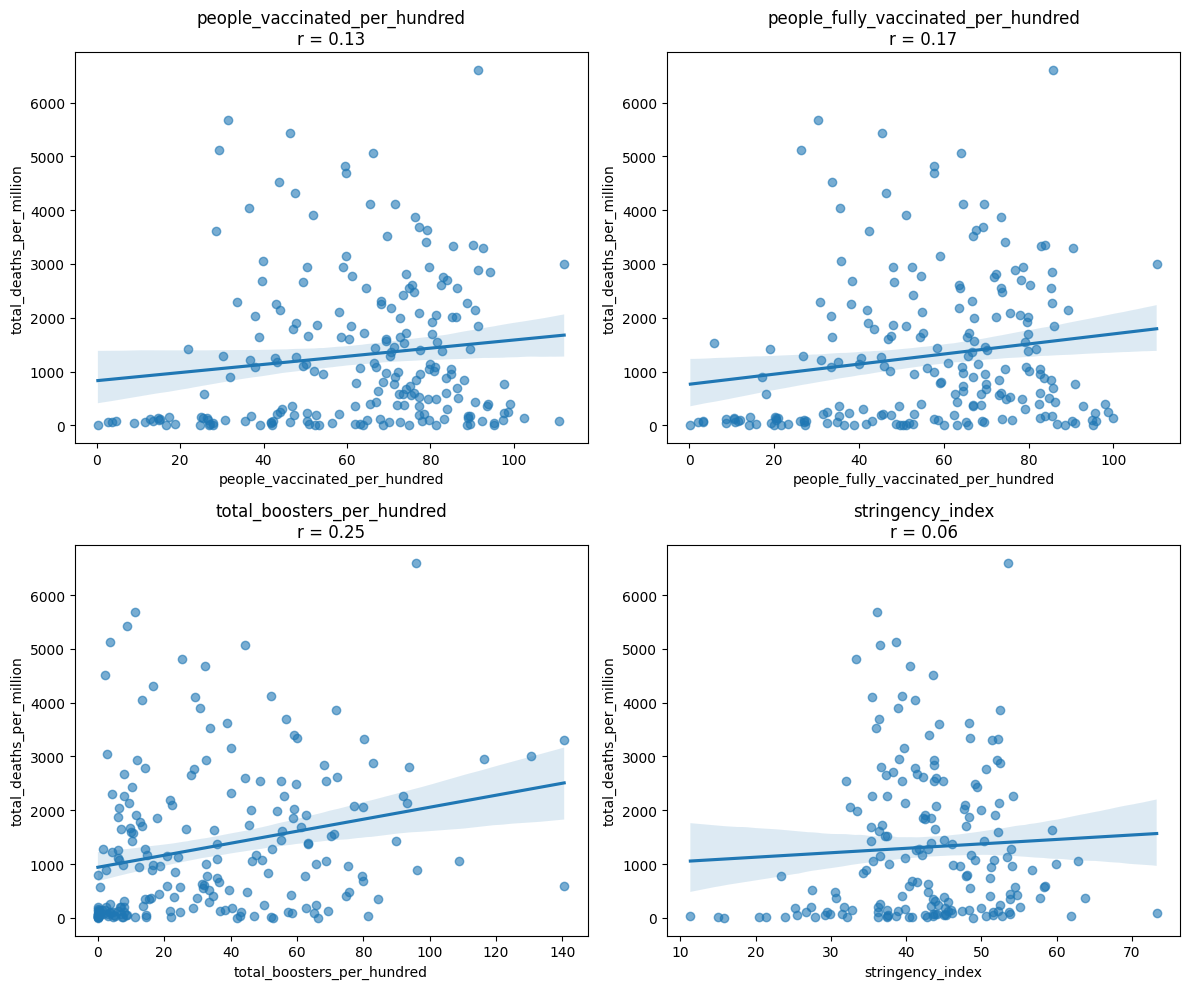

In [28]:
vars_to_plot = [
    "people_vaccinated_per_hundred",
    "people_fully_vaccinated_per_hundred",
    "total_boosters_per_hundred",
    "stringency_index"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, var in zip(axes.flatten(), vars_to_plot):

    sns.regplot(
        data=covid,
        x=var,
        y="total_deaths_per_million",
        scatter_kws={"alpha": 0.6},
        ax=ax
    )

    corr = covid[var].corr(
        covid["total_deaths_per_million"]
    )

    ax.set_title(f"{var}\nr = {corr:.2f}")

plt.tight_layout()
plt.show()

### Vaccination and Government Response

Vaccination variables exhibited weak positive correlations with COVID-19 mortality, ranging from 0.13 for people vaccinated per hundred to 0.25 for booster doses per hundred. Although these relationships appear counterintuitive, they likely reflect underlying differences in population age structure, healthcare systems, and vaccine availability rather than a direct causal relationship.

The Stringency Index exhibited virtually no linear relationship with mortality (r = 0.06). Countries with stricter average government responses did not consistently experience lower mortality rates.

These findings illustrate the limitations of simple pairwise analyses and suggest that multiple demographic, economic, and healthcare factors may simultaneously influence mortality outcomes.

## COVID-19 Mortality by Continent

Country-level analyses provide useful insight into individual predictors of mortality. However, broader geographic patterns may also exist due to differences in demographics, healthcare systems, economic development, public health responses, and reporting practices.

This section examines the distribution of COVID-19 mortality across continents.

In [29]:
covid.groupby("continent")[
    "total_deaths_per_million"
].describe()

,count,mean,std,min,25%,50%,75%,max
continent,,,,,,,,
Africa,56.0,319.455793,505.091520,0.00000,33.023737,101.823403,320.97334,2427.7730
Asia,47.0,671.103097,820.485415,0.00000,160.779015,433.444180,965.17035,4519.6274
Europe,51.0,2696.359382,1369.239720,0.00000,1653.887300,2616.891400,3649.27120,5681.0405
North America,41.0,1541.123804,868.179319,36.40058,893.849850,1572.428600,2100.42360,3625.3750
Oceania,24.0,576.504141,677.890586,0.00000,96.057120,339.390335,885.56440,2536.4270
South America,14.0,2387.437241,1587.236765,0.00000,1661.065325,2262.897100,2925.86350,6603.9766


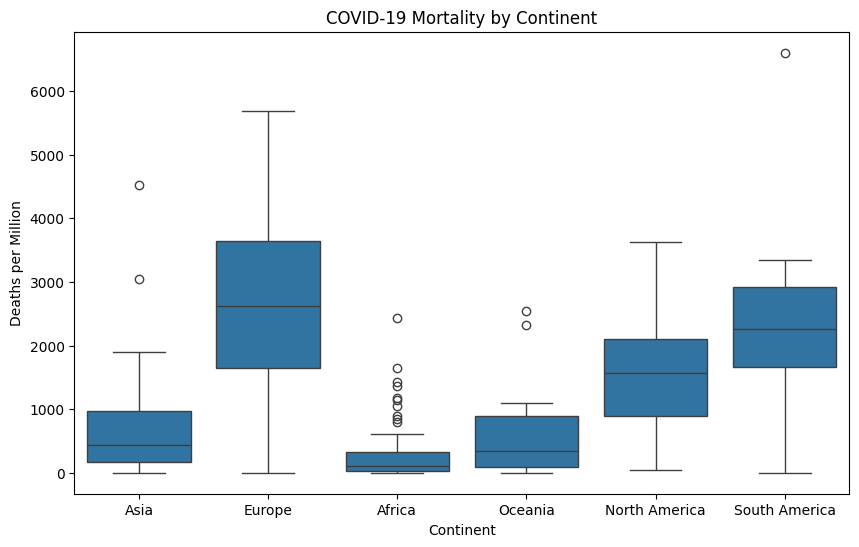

In [30]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=covid,
    x="continent",
    y="total_deaths_per_million"
)

plt.title("COVID-19 Mortality by Continent")
plt.xlabel("Continent")
plt.ylabel("Deaths per Million")

plt.show()

In [31]:
continent_summary = covid.groupby("continent").agg(
    mortality_median=("total_deaths_per_million", "median"),
    mortality_mean=("total_deaths_per_million", "mean"),
    median_age=("median_age", "median"),
    life_expectancy=("life_expectancy", "median")
)

continent_summary.sort_values(
    "mortality_median",
    ascending=False
)

,mortality_median,mortality_mean,median_age,life_expectancy
continent,,,,
Europe,2616.891400,2696.359382,41.960999,80.793297
South America,2262.897100,2387.437241,28.953000,76.137150
North America,1572.428600,1541.123804,37.119999,76.180397
Asia,433.444180,671.103097,29.299500,74.383602
Oceania,339.390335,576.504141,27.475000,71.550301
Africa,101.823403,319.455793,18.466500,65.123150


### Continental Differences in Mortality

Substantial differences in COVID-19 mortality were observed across continents. Europe exhibited both the highest median age and the highest median mortality rate, while Africa exhibited the youngest population and the lowest mortality rate. These findings are consistent with earlier analyses showing a positive relationship between population age and mortality.

However, age structure alone does not fully explain the observed variation. South America experienced considerably higher mortality than Asia despite similar median ages and life expectancies. This suggests that additional demographic, healthcare, economic, policy, or reporting factors may have contributed to differences in pandemic outcomes across regions.

Overall, the continent-level analysis supports the importance of population age while highlighting the multifactorial nature of COVID-19 mortality.

## Distribution and Transformation of Key Variables

Many statistical and machine learning methods perform best when predictor and outcome variables are reasonably symmetric and not dominated by extreme values. Highly skewed distributions can increase the influence of outliers and make relationships more difficult to interpret.

This section examines the distributions of several key variables used throughout the analysis:

- Total COVID-19 deaths per million population
- Total COVID-19 cases per million population
- GDP per capita

For each variable, both the original distribution and a logarithmic transformation are evaluated. The log transformation can reduce skewness, compress extreme values, and potentially improve the performance and interpretability of subsequent predictive models.

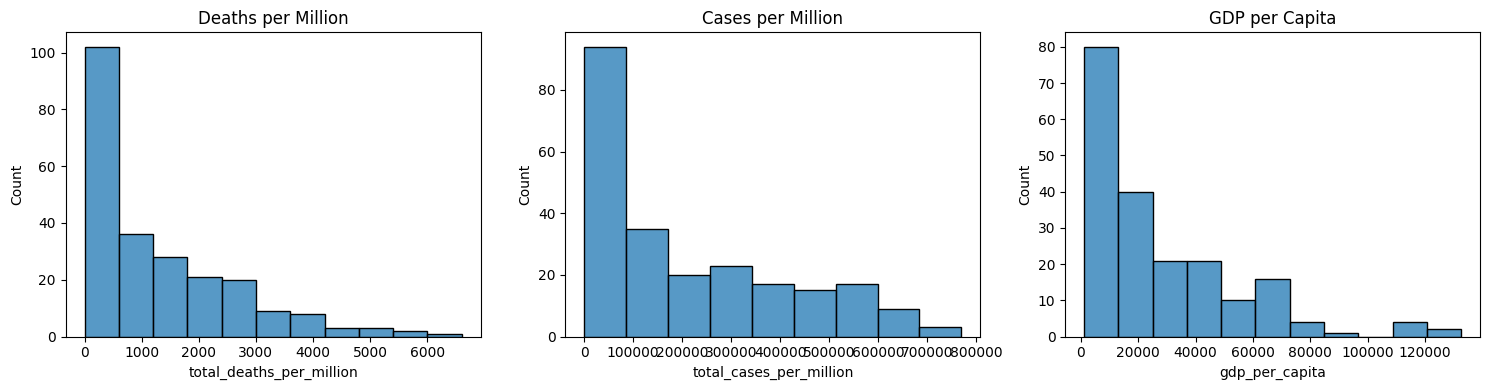

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(
    covid["total_deaths_per_million"].dropna(),
    ax=axes[0]
)
axes[0].set_title("Deaths per Million")

sns.histplot(
    covid["total_cases_per_million"].dropna(),
    ax=axes[1]
)
axes[1].set_title("Cases per Million")

sns.histplot(
    covid["gdp_per_capita"].dropna(),
    ax=axes[2]
)
axes[2].set_title("GDP per Capita")

plt.tight_layout()
plt.show()

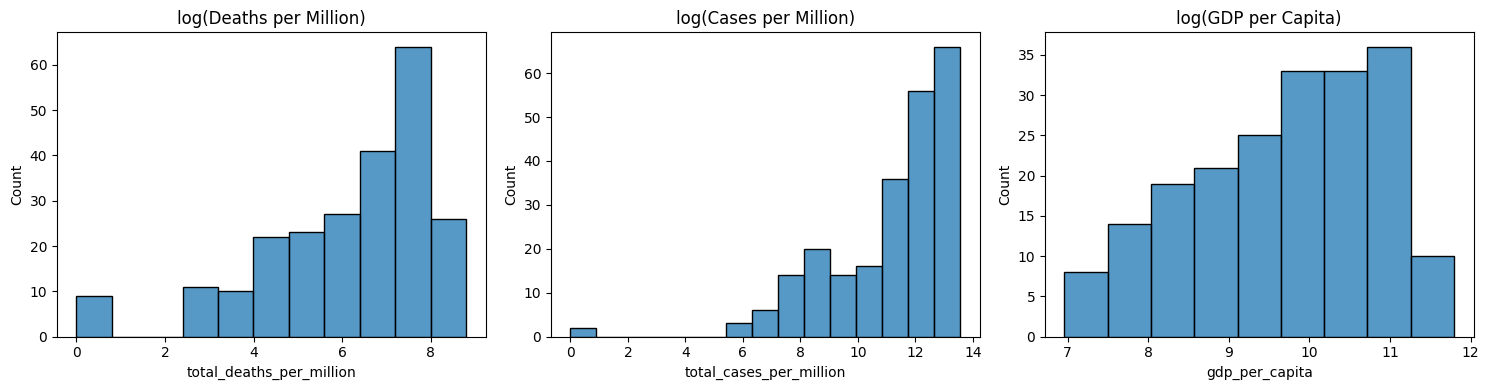

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(
    np.log1p(covid["total_deaths_per_million"]),
    ax=axes[0]
)
axes[0].set_title("log(Deaths per Million)")

sns.histplot(
    np.log1p(covid["total_cases_per_million"]),
    ax=axes[1]
)
axes[1].set_title("log(Cases per Million)")

sns.histplot(
    np.log1p(covid["gdp_per_capita"]),
    ax=axes[2]
)
axes[2].set_title("log(GDP per Capita)")

plt.tight_layout()
plt.show()

### Effect of Log Transformation

All three variables exhibited substantial right-skewness in their original form, with most countries concentrated at lower values and a relatively small number of countries exhibiting extreme values.

Logarithmic transformation reduced skewness for each variable and produced more balanced distributions. The transformation was particularly effective for GDP per capita, which became substantially more symmetric after transformation. Similar improvements were observed for total deaths per million and total cases per million.

These results suggest that log-transformed versions of these variables may be appropriate candidates for subsequent predictive modeling, as they may reduce the influence of extreme observations and improve model stability.

## Regional Comparison: Asia vs. South America

The continent-level analysis revealed a notable difference between Asia and South America. Despite having similar median ages and life expectancies, South America experienced substantially higher COVID-19 mortality than Asia.

This observation raises an important question: if age structure is a major determinant of mortality, why did two regions with comparable demographic characteristics experience such different outcomes?

To explore this question, key demographic, economic, healthcare, vaccination, and policy-related indicators are compared between Asia and South America. The goal is to identify factors that may help explain the large disparity in mortality observed between these regions.

In [34]:
covid[
    covid["continent"].isin(["Asia", "South America"])
].groupby("continent").agg(
    mortality=("total_deaths_per_million", "median"),
    cases=("total_cases_per_million", "median"),
    vaccinated=("people_vaccinated_per_hundred", "median"),
    fully_vaccinated=("people_fully_vaccinated_per_hundred", "median"),
    boosters=("total_boosters_per_hundred", "median"),
    stringency=("stringency_index", "median"),
    gdp=("gdp_per_capita", "median"),
    beds=("hospital_beds_per_thousand", "median")
)

,mortality,cases,vaccinated,fully_vaccinated,boosters,stringency,gdp,beds
continent,,,,,,,,
Asia,433.44418,75670.770,75.07680,66.85257,35.021000,46.141214,17484.132812,2.33
South America,2262.89710,133927.355,83.13468,71.90879,45.916398,51.026036,19179.101562,1.82


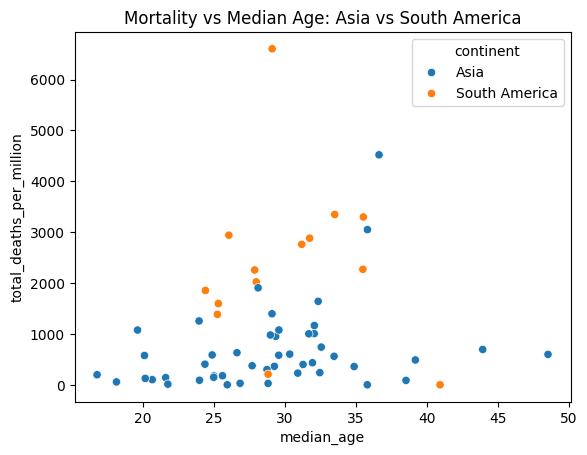

In [35]:
asia_sa = covid[
    covid["continent"].isin(["Asia", "South America"])
]

sns.scatterplot(
    data=asia_sa,
    x="median_age",
    y="total_deaths_per_million",
    hue="continent"
)

plt.title("Mortality vs Median Age: Asia vs South America")
plt.show()

In [38]:
asia = covid[covid["continent"] == "Asia"]
sa = covid[covid["continent"] == "South America"]

asia["total_deaths_per_million"].median()
sa["total_deaths_per_million"].median()

print(asia["total_deaths_per_million"].corr(asia["median_age"]),
      sa["total_deaths_per_million"].corr(sa["median_age"]))

0.2933376674926094 -0.08040661067473921


### Findings from the Asia–South America Comparison

Despite similar median ages, life expectancies, and levels of economic development, South America experienced substantially higher COVID-19 mortality than Asia. South America also reported nearly twice as many cases per million population, suggesting that a higher infection burden may have contributed to the observed mortality differences.

Vaccination coverage and booster uptake were generally higher in South America, indicating that differences in vaccination rates are unlikely to explain the mortality gap. Government stringency measures were also broadly similar between the two regions.

One notable difference is hospital bed availability, which was somewhat higher in Asia. While this factor alone is unlikely to account for the entire disparity, it may reflect broader differences in healthcare system capacity.

Further analysis revealed that the relationship between median age and mortality differed across regions. Within Asia, a modest positive correlation was observed between median age and mortality (r = 0.29), whereas virtually no relationship was observed within South America (r = -0.08). This suggests that age structure may help explain mortality differences between continents, but does not adequately explain variation within South America.

Overall, the comparison suggests that age structure is not sufficient to explain global mortality patterns and that multiple factors likely contributed to regional differences in pandemic outcomes.

# Modeling Considerations

The exploratory analysis identified several variables that may be useful predictors of COVID-19 mortality. However, EDA also revealed potential challenges related to multicollinearity, missing data, and variable distributions.

This section summarizes key findings from the exploratory analysis and outlines considerations for the predictive modeling phase of the project.

### Candidate Predictors

Based on the exploratory analysis, several variables demonstrated meaningful relationships with COVID-19 mortality and may be considered for inclusion in predictive models.

Key candidate predictors include:

- Median age
- Life expectancy
- Total cases per million population
- GDP per capita
- Hospital beds per thousand
- Vaccination coverage measures
- Government stringency index

These variables capture demographic, epidemiological, economic, healthcare, and policy-related characteristics that may influence mortality outcomes.

### Multicollinearity Considerations

Several predictor variables exhibited substantial correlations with one another. For example, median age and life expectancy were strongly correlated (r = 0.77), while GDP per capita was positively associated with both life expectancy (r = 0.67) and total cases per million (r = 0.70).

These relationships suggest that some predictors may contain overlapping information. Future modeling efforts should evaluate whether highly correlated variables should be combined, transformed, or excluded to reduce redundancy and improve model interpretability.

### Missing Data Considerations

Most variables exhibited relatively low levels of missingness. However, several healthcare and policy variables contained more substantial gaps, including:

- Hospital beds per thousand (29.7% missing)
- Stringency Index (22.6% missing)
- Health expenditure variables (approximately 19% missing)

Modeling approaches may require imputation, variable exclusion, or sensitivity analyses to address missing data appropriately.

### Variable Transformations

Several variables, including total deaths per million, total cases per million, and GDP per capita, exhibited substantial right-skewness. Logarithmic transformations substantially reduced skewness and produced more balanced distributions.

As a result, both original and log-transformed versions of these variables should be considered during model development and evaluation.

### Target Variable

The primary outcome variable for predictive modeling will be total COVID-19 deaths per million population. Exploratory analysis demonstrated substantial variation across countries, making this variable well suited for investigating country-level factors associated with mortality.

Future modeling efforts will focus on identifying the combination of demographic, healthcare, economic, vaccination, and policy variables that best explain variation in mortality outcomes across countries.